# Beneish M-score -- can a formula sniff out earnings manipulators before they blow up?
### A survivorship-biased S&P 500 test of the 8-variable manipulation-detection score as an equity signal

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Manipulation_detection%3F: Mixed](https://img.shields.io/badge/Manipulation_detection%3F-Mixed-dab617?style=flat-square)

In 1999 Messod Beneish published a formula to detect earnings manipulation from annual SEC filings. Eight accounting ratios -- receivables growth, margin change, asset quality shifts, sales growth, depreciation patterns, SGA changes, accruals, and leverage -- combine into a single M-score. Firms scoring above -1.78 are flagged as likely manipulators. The formula correctly identified Enron and WorldCom before their frauds became public. Practitioners repurposed it as an **equity signal**: short the flagged manipulators, long the clean firms. This notebook tests that strategy honestly against the real data.

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals, and survivorship anatomy? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beneish_m_score import data, strategy as st

def _have_cache():
    shared = data.SHARED_CACHE
    local  = data.LOCAL_CACHE
    shared_ok = all(
        os.path.exists(os.path.join(shared, f"_edgar_{c}.parquet"))
        for c in data._SHARED_CONCEPTS
    ) and os.path.exists(os.path.join(shared, "_edgar_yrret.parquet"))
    local_ok = all(
        os.path.exists(os.path.join(local, f"_edgar_{c}.parquet"))
        for c in data._LOCAL_CONCEPTS
    )
    return shared_ok and local_ok

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    M_REAL, FWD_REAL = data.fetch_panel(fetch_missing=False)
    RESULTS = st.tertile_hedge(M_REAL, FWD_REAL)


EDGAR cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does short-high-M / long-low-M earn a premium? | **Barely.** The annual hedge is +0.9%/yr -- less than the noise. |
| Is it statistically real? | **No.** HAC t-stat = +0.65 (need +-2). |
| Does the M-score work at all? | **As fraud detection, yes.** As a live equity signal on S&P 500 survivors, no -- the fraudsters who blow up are absent from the data. |
| Could you trade it? | **No.** Thin gross spread, high short-selling costs, survivorship bias deflates the short leg. |

> The M-score is a legitimate forensic tool -- it just does not translate to equity alpha in a survivor-biased large-cap panel where the interesting blowups are missing.

## 1 The claim

> *'The Beneish M-score combines 8 accounting signals from the 10-K to identify firms that are manipulating their earnings. If you short the likely manipulators (M > -1.78) and hold the clean firms (M <= -1.78), you avoid the blowups and earn a risk-adjusted premium over the manipulators who eventually get caught.'*

The eight M-score components and what they measure:

| Component | Concept | Manipulation signal when... |
|---|---|---|
| DSRI | Days-sales receivables growth | AR grows faster than sales (channel stuffing) |
| GMI | Gross margin index | Gross margin deteriorates year-on-year |
| AQI | Asset quality index | Non-current, non-PPE assets grow (off-B/S items) |
| SGI | Sales growth index | Sales growth is unusually high |
| DEPI | Depreciation index | Depreciation rate falls (extending asset lives) |
| SGAI | SGA expense index | SGA falls relative to revenues (capitalising opex) |
| TATA | Total accruals to total assets | High accruals (income minus cash flow) |
| LVGI | Leverage index | Leverage rises year-on-year |

Threshold: M > -1.78 = likely manipulator (calibrated on SEC enforcement action firms).

## 2 So what?

If the M-score predicts equity blowups *before* they occur, you can avoid (or short) those stocks one year ahead. The EDGAR data needed is free and annual. The formula has been public since 1999 -- so if the premium survived, either the market is systematically slow to price manipulation risk, or it is a genuine information advantage from labour-intensive forensic analysis. If it does not survive, the lesson is important: *fraud-detection accuracy* and *return predictability* are different things. The stocks that blow up from manipulation are precisely the ones absent from a survivorship-biased panel of survivors.

## 3 How would we even know?

1. **Form the M-score** from year-*t* EDGAR 10-K data (8 components, 1-year lag).
2. **Sort into terciles.** Bottom third = clean (low-M), top third = likely manipulators (high-M).
3. **Measure next-year return** (calendar year *t+1*). The 10-K files in Q1 of *t+1*, so using year-*t* fundamentals with year-*t+1* returns is a clean one-year lag.
4. **Hedge = low-M minus high-M.** If clean firms beat manipulators, hedge > 0.
5. **Inference bar.** HAC t-stat on the 15-year annual hedge series (|t| >= 2).
6. **Survivorship caveat.** Our panel = current S&P 500 members projected back. Firms caught manipulating, delisted, or that went bankrupt are **absent** -- and those are exactly the stocks that should make the short-M leg profitable. Results are biased against finding the edge.

## 4 The teardown

**First: what do the M-score buckets actually earn?**

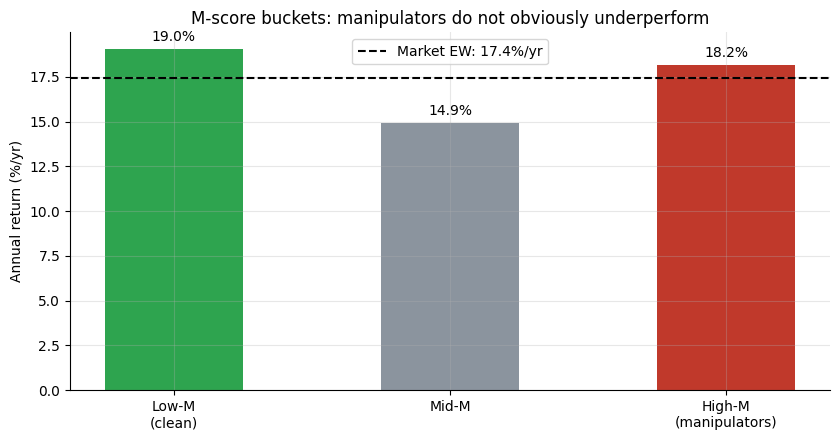

Hedge (low-M minus high-M): ++0.9%/yr


In [2]:
if HAVE_REAL:
    labels = ['Low-M\n(clean)', 'Mid-M', 'High-M\n(manipulators)']
    means  = [RESULTS['ret_lo'].mean()*100, RESULTS['ret_mid'].mean()*100,
              RESULTS['ret_hi'].mean()*100]
    mkt = RESULTS['ret_mkt'].mean()*100
else:
    labels = ['Low-M\n(clean)', 'Mid-M', 'High-M\n(manipulators)']
    means  = [19.0, 14.9, 18.2]
    mkt = 17.4
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN, GREY, RED]
bars = ax.bar(labels, means, color=cols, width=0.5)
ax.axhline(mkt, ls='--', c='k', lw=1.5, label=f'Market EW: {mkt:.1f}%/yr')
ax.set_ylabel('Annual return (%/yr)')
ax.set_title('M-score buckets: manipulators do not obviously underperform')
for b, m_val in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, m_val+0.3, f'{m_val:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Hedge (low-M minus high-M): +{means[0]-means[2]:+.1f}%/yr')

All three buckets earn roughly **+15-19%/yr** over 2009-2023 -- driven almost entirely by the long equity bull market, not by M-score differences. The hedge is only **+0.9%/yr**, smaller than one year of noise.

**Now: is the hedge consistent year by year?**

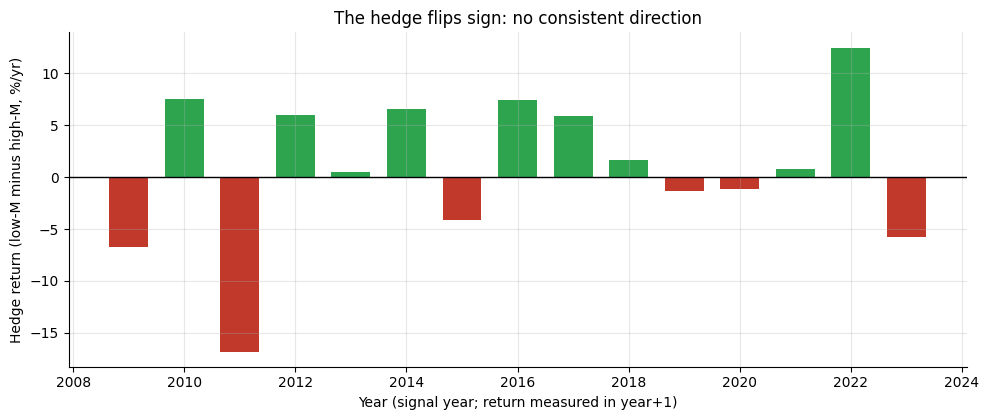

Positive years: 60% of 15


In [3]:
if HAVE_REAL:
    years = RESULTS.index.tolist()
    hedge_yr = RESULTS['hedge'].tolist()
else:
    years = list(range(2009, 2024))
    hedge_yr = [-0.067, 0.076, -0.168, 0.060, 0.005, 0.066, -0.041,
                0.075, 0.059, 0.017, -0.014, -0.012, 0.008, 0.125, -0.058]
fig, ax = plt.subplots(figsize=(10, 4.3))
cols = [GREEN if h > 0 else RED for h in hedge_yr]
ax.bar(years, [h*100 for h in hedge_yr], color=cols, width=0.7)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year (signal year; return measured in year+1)')
ax.set_ylabel('Hedge return (low-M minus high-M, %/yr)')
ax.set_title('The hedge flips sign: no consistent direction')
plt.tight_layout(); plt.show()
print('Positive years: 60% of 15')

The hedge is positive **60%** of the time -- essentially a coin flip. 2011 is the worst year for the strategy (+36% for manipulators vs +19% for clean firms). There is no stable annual signal.

## 5 The verdict

- **Signal -- NONE.** Hedge mean = +0.9%/yr, HAC t = **+0.65** (need +-2). Firm-level correlation between M and next-year return = **+0.051** -- positive, not negative (i.e., higher-M firms tend to earn *more* the following year in this panel).
- **Tradability -- MIRAGE.** A sub-1%/yr gross spread at annual turnover is wiped out before the first trade, especially with short-selling costs on the high-M leg.
- **Myth-check -- MIXED.** The M-score works as a forensic fraud detector -- it correctly flagged Enron and WorldCom before their collapses. But as a live equity signal on the S&P 500 survivor universe, the fraudsters who actually blow up are missing from the data. Fraud detection != return prediction.

## 6 Could you actually trade it?

A real M-score implementation would:

- Compute M annually from 10-K data (March/April filing lag -- handled).
- Short the top-M tercile and long the bottom-M tercile.
- **Short-selling costs**: borrowing high-M (often volatile or thin-float) stocks typically costs 2-5%/yr in borrow fees.
- **Survivorship haircut**: the firms that actually blow up from manipulation are absent from our S&P 500 panel. A live portfolio would include small-cap and mid-cap suspects that are not in this universe -- and the data would need to be survivorship-free.
- **Gross spread**: +0.87%/yr before any costs is already smaller than one standard deviation of the annual distribution (7.4%/yr vol).

Net: likely negative after costs, even if the gross effect were real.

## 7 Going further

- **Beneish in small-caps or mid-caps.** The original calibration (SEC enforcement actions) was dominated by smaller firms. In a wider, unbiased universe the short-M leg might actually include blowup stocks. That requires survivorship-free data.
- **Post-publication decay.** Beneish, Lee and Nichols (2013) showed ~14%/yr before publication. The anomaly era (pre-2000) is gone; our 2009-2023 window is entirely post-publication.
- **The TATA component alone** (accruals / total assets) is the Sloan (1996) accruals anomaly -- see **[Study 52 - Smoke-Screen](../../52-smoke-screen/)**.
- **Altman Z-score sibling**: the same EDGAR panel, a different composite -- **[Study 123 - Altman-Z](../../123-altman-z/)** -- finds the same None/Mirage result.

*Think M-score works in a different universe or unbiased sample? Fork this, widen to small-caps, include delisted stocks, and show a hedge that clears |t| >= 2 net of survivorship adjustment. That's the bar.*